In [51]:
# data creation

import numpy as np
x_range = 1000 # size of the trajectory 
v       = 1 # desired constant speed
v_max   = 2 # maximum possible velocity

# pre-flight course defined by velocity
planned_v_traj = np.array([v for t in range(x_range)]) 

# uniformly distributed wind
unif_wind_traj = np.random.choice([-1, 0, 1], size=1000, p=[0.2, 0.6, 0.2])

In [50]:
# no spoofing

spoofing_bias = np.zeros(x_range)

# satellite visibility @ spoof
num_sats_spf         = np.random.choice([0, 1, 2], size=1000, p=[0.2, 0.6, 0.2])

# satellite visibility @ benign
num_sats_ben         = np.random.choice([2, 3, 4], size=1000, p=[0.2, 0.2, 0.6])

# satellite visibility @ spoof + benign
num_sat              = num_sats_ben
mask                 = spoofing_bias>0
num_sat[mask]        = num_sats_spf[mask]


# expected gps velocities
gps_ben_traj  =  planned_v_traj

# benign/no-spoofing body velocity
body_ben_traj      = gps_ben_traj - unif_wind_traj

# residual
residual         = gps_ben_traj - body_ben_traj

# saturation
saturation       = (np.abs(body_ben_traj) > v_max).astype(int)

In [52]:
# spoofing strategy 1: delay

# 200->299, add +1 spoofing bias, 300->399 add +2 spoofing bias, 400->499 add +1 spoofing bias

spoofing_bias = np.zeros(x_range)
spoofing_bias[200:300] +=1
spoofing_bias[300:400] +=2
spoofing_bias[400:500] +=1

# satellite visibility @ spoof
num_sats_spf         = np.random.choice([0, 1, 2], size=1000, p=[0.2, 0.6, 0.2])

# satellite visibility @ benign
num_sats_ben         = np.random.choice([2, 3, 4], size=1000, p=[0.2, 0.2, 0.6])

# satellite visibility @ spoof + benign
num_sat              = num_sats_ben
mask                 = spoofing_bias>0
num_sat[mask]        = num_sats_spf[mask]


# spoofed gps velocities
gps_spf_traj     = planned_v_traj + spoofing_bias

# spoofed body velocity
body_spf_traj    = gps_spf_traj - unif_wind_traj

# residual
residual         = gps_spf_traj - body_spf_traj

# saturation
saturation       = (np.abs(body_spf_traj) > v_max).astype(int)


In [53]:
# probability mass functions

# residual p(r_s = k|G = i,W = j) ~ i={0,1} x j={-1, 0, 1}  x k={-3, -2, -1, 0, 1 , 2, 3}

# convert actual values to indices
def G(i): return i  # 0->0, 1->1
def W(j): return j + 1  # shift -1->0, 0->1, 1->2
def rs(k): return k + 3  # shift -2->0, -1->1, 0->2, 1->3, 2->4

pmf_res = np.zeros((7, 2, 3))
pmf_res[rs(0), G(0), W(0)]  = 1   #  p(r_s = 0|G = 0,W = 0) = 1
pmf_res[rs(0), G(1), W(-1)] = 1/4
pmf_res[rs(1), G(0), W(1)] = 1
pmf_res[rs(1), G(1), W(0)] = 1/4
pmf_res[rs(1), G(1), W(-1)] = 1/4
pmf_res[rs(-1), G(0), W(-1)] = 1
pmf_res[rs(-1), G(1), W(0)] = 1/4
pmf_res[rs(-1), G(1), W(1)] = 1/4
pmf_res[rs(-2), G(1), W(0)] = 1/4
pmf_res[rs(-2), G(1), W(-1)] = 1/4
pmf_res[rs(2), G(1), W(0)] = 1/4
pmf_res[rs(2), G(1), W(1)] = 1/4
pmf_res[rs(-3), G(1), W(-1)] = 1/4
pmf_res[rs(3), G(1), W(1)] = 1/4

# saturation p(s = k|G = i,W = j) i={0,1} x j={-1, 0, 1}  x k={0,1}

def s(k): return k  # 0->0, 1->1

pmf_sat = np.zeros((2, 2, 3))
pmf_sat[s(0), G(0), W(0)] = 1  # p(s = 0|G = 0,W = 0) = 1
pmf_sat[s(0), G(0), W(1)] = 1  
pmf_sat[s(0), G(1), W(-1)] = 1/2
pmf_sat[s(0), G(1), W(0)] = 1/2
pmf_sat[s(0), G(1), W(1)] = 1/2
pmf_sat[s(1), G(1), W(-1)] = 1/2
pmf_sat[s(1), G(1), W(0)] = 1/2
pmf_sat[s(1), G(1), W(1)] = 1/2
pmf_sat[s(1), G(0), W(-1)] = 1

# number of visible sats p(Q = i|G = j) j={0,1} x i={0,1,2,3,4} 

def Q(i): return i  

pmf_satel = np.zeros((5, 2))
pmf_satel[Q(0), G(1)] = 1/5
pmf_satel[Q(2), G(1)] = 1/5
pmf_satel[Q(1), G(1)] = 3/5
pmf_satel[Q(4), G(0)] = 3/5
pmf_satel[Q(3), G(0)] = 1/5
pmf_satel[Q(2), G(0)] = 1/5



In [105]:
# transition matrix and the initial distribution
def build_T_and_pi(alpha, beta):
    # alpha = liklihood of spoofing between successive t's, 1-beta = persistence of spoofing attack
    A = np.array([[1 - alpha, alpha],
                  [beta, 1 - beta]], float)
    # state transition for wind: i.i.d, but most likely to be 0, equally likely to be 1 or -1
    B = np.tile(np.array([0.2, 0.6, 0.2]), (3, 1))  
    T = np.kron(A, B)                               # kronecker product -> transition matrix
    # prior distribution
    pi_G = np.array([beta, alpha])/(alpha+beta)     # uninformative prior
    pi_W = np.array([1/5,3/5,1/5])
    pi  = np.kron(pi_G, pi_W)                       # length-6
    return T, pi

In [106]:
# emission distribution b(t) over 6 joint states (G,W) in [(0,−1),(0,0),(0,1),(1,−1),(1,0),(1,1)]
def emission_row(res_t, sat_t, q_t, pmf_res, pmf_sat, pmf_satel, epsilon=1e-12):
    b = np.zeros(6, float) 
    j = 0
    resid = int(rs(res_t))
    for g in (0,1):
        for w in (-1,0,1):
            wind = int(W(w))
            # the emission model consists of independent r.vs
            p = pmf_res[resid, g, wind] * pmf_sat[ int(sat_t), g, wind] * pmf_satel[int(q_t), g]
            # dealing with underflow
            b[j] = max(p, epsilon)
            j += 1
    return b / b.sum() # normalize

In [107]:
# computes forward parameter alpha
def forward_filter(residual, saturation, num_sat, pmf_res, pmf_sat, pmf_satel,
                   alpha=0.005, beta=0.05):
    T, pi = build_T_and_pi(alpha, beta)
    T = T / T.sum(axis=1, keepdims=True)  # stochastic
    T = np.asarray(T)

    T_len = len(residual)
    alpha_hat = np.zeros((T_len, 6), float)
    # t = 0
    b0 = emission_row(residual[0], int(saturation[0]), int(num_sat[0]),
                      pmf_res, pmf_sat, pmf_satel)
    a = pi * b0
    a = a / a.sum()
    alpha_hat[0] = a
    # t > 0
    for t in range(1, T_len):
        bt = emission_row(residual[t], int(saturation[t]), int(num_sat[t]),
                          pmf_res, pmf_sat, pmf_satel)
        a = bt * (a @ T)         # element wise multiply by predicted prior
        s = a.sum()
        if s == 0.0:             # avoid dividing by zero       
            a = np.ones_like(a) / len(a)
        else:
            a /= s # normalize
        alpha_hat[t] = a
    # marginalized filtering over G
    # order: [(0,−1),(0,0),(0,1),(1,−1),(1,0),(1,1)]
    P_G0 = alpha_hat[:, 0] + alpha_hat[:, 1] + alpha_hat[:, 2]
    P_G1 = alpha_hat[:, 3] + alpha_hat[:, 4] + alpha_hat[:, 5]
    # normalize 
    Z = P_G0 + P_G1
    P_G0, P_G1 = P_G0/Z, P_G1/Z
    return P_G0, P_G1, alpha_hat

In [108]:
p_G0, p_G1, alpha_h = forward_filter(residual, saturation, num_sat, pmf_res, pmf_sat, pmf_satel,
                   alpha=0.005, beta=0.0001)

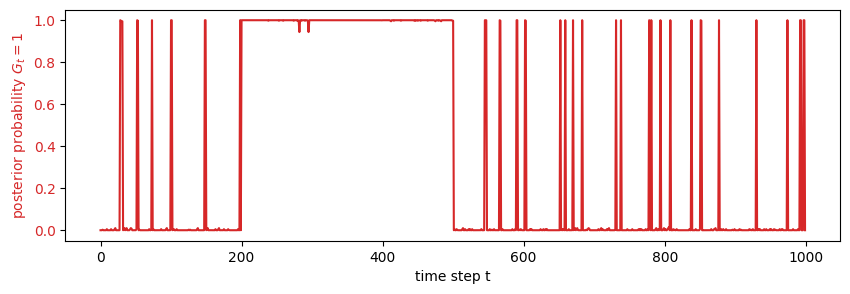

In [109]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,3))
ax1.plot(p_G1, color='tab:red', label=r'$P(G_t=1\mid o_{1:t})$')
ax1.set_xlabel('time step t')
ax1.set_ylabel('posterior probability $G_t =1$', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# ax2 = ax1.twinx()
# ax2.plot(unif_wind_traj, color='tab:blue', alpha=0.4, lw=1.0, label='wind $W_t$')
# ax2.set_ylabel('wind state', color='tab:blue')
# ax2.set_yticks([-1, 0, 1])
# ax2.tick_params(axis='y', labelcolor='tab:blue')